# Creating a sample of M stars between 50 and 200pc

Benjamin Pennell

--

Max Planck Institut für Astronomie, Heidelberg

---

In [1]:
from utils.dependencies import *;

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import h5py
import pyvo
from astroquery.gaia import Gaia
import matplotlib.patheffects as pe

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


## Setup

#### Load in the full kpc XP catalogue and take the relevant columns

In [51]:
msms = h5py.File("../BigData/msms_36m_v0.hdf5", "r")
new_table = Table()
labels = ["source_id", "parallax", "ra", "dec", "phot_g_mean_mag", "mass_single", "m1_binary", "m2_binary", "predicted_class", "bp_rp", "mh_single", "q_binary", "flux_ratio_mean", "flux_ratio_std", "chi2_mass_mh", "chi2_mass_mh_binary", "chi2_diff_mh_mass", "fit_success_single", "fit_success_binary"]
for label in labels:
    new_table.add_column(np.array(msms["table"]["columns"][label]["data"]), name=label)

#### Cut to nearby objects in our target mass range

In [ ]:
PARALLAX_MASK = (new_table["parallax"] < 20) & (new_table["parallax"] > 5) # 50-200pc
MASS_MASK = (new_table["mass_single"] < 1.2) & (new_table["mass_single"] > 0.2)
SUCCESS_CUT = (new_table["fit_success_binary"]) & (new_table["fit_success_single"])
total_mask = PARALLAX_MASK & MASS_MASK & SUCCESS_CUT
working_table = new_table[total_mask]

#### Save everything within 200pc

In [56]:
def chunk_list(lst, n):
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

batch_size = 25000

everything = []
counter = 0

for batch in tqdm(list(chunk_list(working_table["source_id"], batch_size))):
    ids_str = ",".join(str(sid) for sid in batch)
    query = f"""
    SELECT *
    FROM gaiadr3.gaia_source
    WHERE source_id IN ({ids_str})
    """
    complete = False
    while not complete:
        try:
            job = Gaia.launch_job_async(query, verbose=False)
            results = job.get_results()
            complete = True
        except:
            print(f"{counter} Failed")
        time.sleep(1)

    everything.append(results.to_pandas())
    counter += 1

everything_df = pd.concat(everything, ignore_index=True)

  0%|          | 0/49 [00:00<?, ?it/s]

INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]


In [59]:
final_df = working_table.to_pandas()

# Merge on source_id
merged_df = final_df.merge(
    everything_df,
    on="source_id",
    how="left",
    suffixes=("", "_gaia")
)

# Convert back to Astropy table if desired
working_table = Table.from_pandas(merged_df)

In [60]:
working_table.write("../BigData/ALL_gaia_source_and_xp_within_200pc.hdf5", path="table", overwrite=True)

#### Crossmatch with NSS catalogue to get orbit solutions

In [131]:
nss_table = Table.read('../BigData/NSSTableKpc.fits', format='fits')
nss_table = nss_table[(nss_table["parallax"] < 20) & (nss_table["parallax"] > 5)]

In [132]:
relevant_things = ["source_id", "parallax", "ra", "dec", "phot_g_mean_mag", "mass_single", "m1_binary", "m2_binary", "predicted_class", "bp_rp", "mh_single", "q_binary", "flux_ratio_mean", "flux_ratio_std", "chi2_mass_mh", "chi2_mass_mh_binary", "chi2_diff_mh_mass", "fit_success_single", "fit_success_binary"]
for col in relevant_things:
    if col not in nss_table.keys():
        nss_table.add_column(np.zeros(len(nss_table)), name=col)

In [133]:
reduced_nss = Table(names=nss_table.colnames, dtype=[nss_table[col].dtype for col in nss_table.colnames])
for obj in tqdm(nss_table):
    source_id = obj["source_id"]
    if source_id in working_table["source_id"]:
        target_row = working_table[working_table["source_id"] == source_id][0]
        for col in relevant_things:
            obj[col] = target_row[col]
                
        reduced_nss.add_row(obj)

  0%|          | 0/16504 [00:00<?, ?it/s]

#### For now, let's focus on the low mass orbit solutions which get $\texttt{predicted\_class}=0$. 
Let's ask the question: What flux ratio does $\texttt{predicted\_class}=0$ correspond to? We'll address this by using isochrones to find what flux ratios different companion masses correspond to, and we'll see where our biggest companion orbit solutions lie. This should indicate the maximum allowable flux ratio.

In [134]:
small_nss = reduced_nss[(reduced_nss["predicted_class"] == 0) & (reduced_nss["mass_single"] < 0.4) & (reduced_nss["mass_single"] > 0.2)]
print(len(small_nss))

292


In [135]:
labels = ["m2", "fm", "m2_flux"]
for label in labels:
    try:
        small_nss.add_column(np.zeros(len(small_nss)), name=label)
    except:
        pass
    
for row in tqdm(small_nss):
    result_row = small_nss[small_nss["source_id"] == row["source_id"]]
    row["fm"] = mass_function(result_row[0])
    row["m2"] = companion_mass(row["mass_single"], row["fm"])
    row["m2_flux"] = companion_mass_phot(row["mass_single"], row["fm"], row["flux_ratio_mean"])

  0%|          | 0/292 [00:00<?, ?it/s]

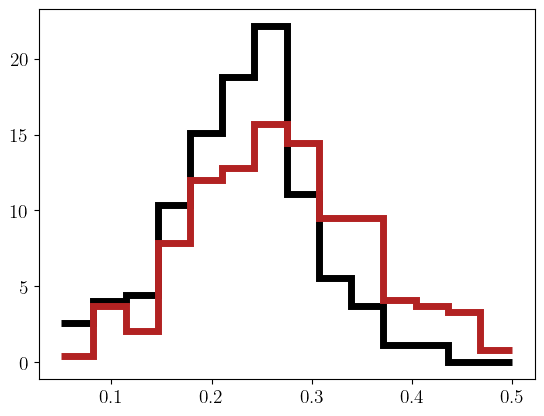

In [153]:
q_bins = np.linspace(0.05,0.5,15)

vals, bins = np.histogram(small_nss["m2"]/small_nss["mass_single"], bins=q_bins)
rates = vals/np.sum(vals)*100
plt.stairs(rates, bins, lw=5, baseline=None, label="Real NSS Objects");

vals, bins = np.histogram(small_nss["m2_flux"]/small_nss["mass_single"], bins=q_bins)
rates = vals/np.sum(vals)*100
plt.stairs(rates, bins, lw=5, baseline=None, label="Real NSS Objects");

## Computing a grid of mass ratio -> flux for all my companions

For a paricular metallicity, take an isochrone. Look at the corresponding magnitudes for your two objects and convert that to a flux ratio.

In our case, at the low mass end, the isochrones only go to $0.1M_\odot$, so we need to extrapolate by fitting a power law (this works quite well)

In [3]:
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
isochrone_data = pd.read_csv('./data/PARSEC_logage_6to10_MH_n2p5_0p6_dwarf.csv')

### Step 1: identify the flux ratio at all valid parts on the isochrone

In [4]:
def flux_ratio(m2, m1, mh, isochrone_data, logAge=9):
    # find the isochrone
    mh_closest = min(np.unique(isochrone_data["MH"]), key=lambda x: abs(x - mh))
    df_mh = isochrone_data[(isochrone_data["MH"] == mh_closest) & (isochrone_data["logAge"] == logAge)].copy()
    df_mh_sorted = df_mh.sort_values('Mini')
    mini_available = df_mh_sorted['Mini'].values
    gmag_available = df_mh_sorted['Gmag'].values
    
    # if the companion is too small, return 0, I'll fill it in later
    if m2 < mini_available.min():
        return 0
    
    # get magnitude for the two masses by interpolating
    interp_gmag = interp1d(mini_available, gmag_available, kind='linear')
    delta_mag = float(interp_gmag(m2)) - float(interp_gmag(m1)) 
    # convert to flux ratio
    flux_ratio = 10**(-0.4*delta_mag) 
    return flux_ratio

In [104]:
q_range = (0.05, 0.5)
mh_range = (-0.5, 0.5)
grid_size = np.array([50, 50, 26])

f_grid = np.zeros(grid_size)
qs = np.linspace(*q_range, grid_size[0])
m1s = np.linspace(0.2, 0.4, grid_size[1])
mhs = np.linspace(*mh_range, grid_size[2])

pbar = tqdm(total=grid_size.prod())
for i, q in enumerate(qs):
    for j, m1 in enumerate(m1s):
        for k, mh in enumerate(mhs):
            model_m2 = q * m1
            model_flux_ratio = flux_ratio(model_m2, m1, mh, isochrone_data)
            f_grid[i,j,k] = model_flux_ratio
            pbar.update(1)

  0%|          | 0/65000 [00:00<?, ?it/s]

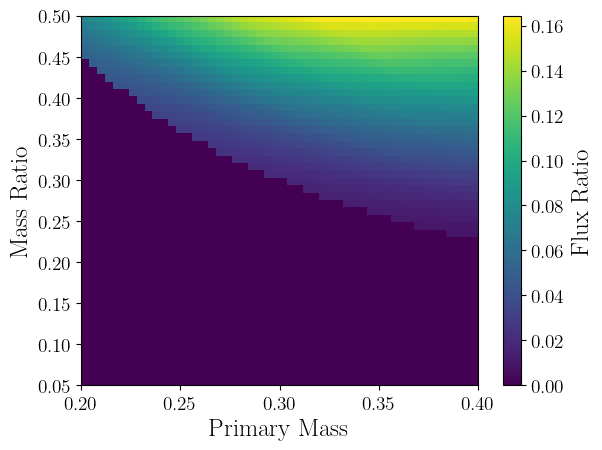

In [105]:
cb = plt.imshow(f_grid[:,:,5], origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), qs.min(), qs.max()]);
plt.xlabel("Primary Mass");
plt.ylabel("Mass Ratio");
plt.colorbar(cb, label="Flux Ratio");

### Step 2: fit power laws along mass ratio axes to fill in remaining spots
here's an example. Approximately gamma=4

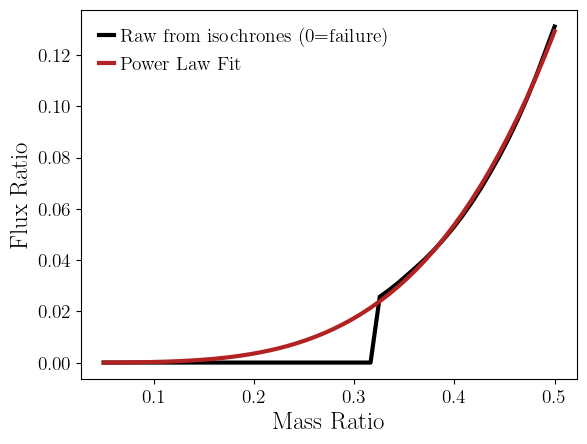

In [53]:
fs = f_grid[:,20,5]
x, y = qs[fs>0], fs[fs>0]
def power_law(x, a, b):
    return a * x**b
popt, pcov = curve_fit(power_law, x, y)
plt.plot(qs, fs, lw=3, label="Raw from isochrones (0=failure)");
plt.plot(qs, power_law(qs, *popt), lw=3, label=f"Power Law Fit");
plt.xlabel("Mass Ratio");
plt.ylabel("Flux Ratio");
plt.legend();

In [106]:
pbar = tqdm(total=grid_size[1]*grid_size[2])
gammas = np.zeros((grid_size[1], grid_size[2]))
for j, m1 in enumerate(m1s):
    for k, mh in enumerate(mhs):
        fs = f_grid[:,j,k]
        x, y = qs[fs>0], fs[fs>0]
        if len(x) > 2: # have enough points to actually fit a power law decently
            # we have enough points in every column for this to work
            popt, pcov = curve_fit(power_law, x, y)
            f_grid[:,j,k] = power_law(qs, *popt)
            gammas[j,k] = popt[1]
        pbar.update(1)

  0%|          | 0/1300 [00:00<?, ?it/s]

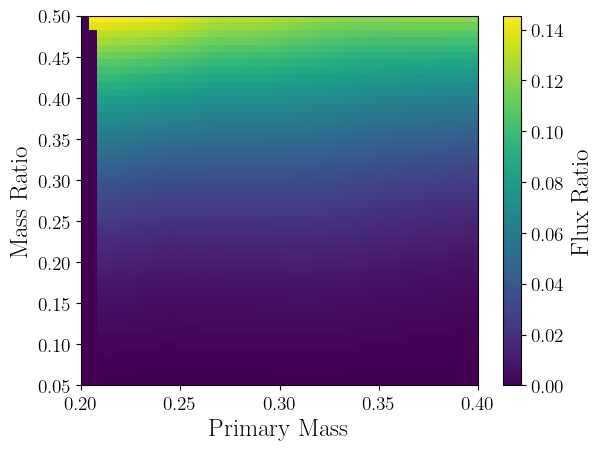

In [110]:
cb = plt.imshow(f_grid[:,:,25], origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), qs.min(), qs.max()]);
plt.xlabel("Primary Mass");
plt.ylabel("Mass Ratio");
plt.colorbar(cb, label="Flux Ratio");

#### simply extend on the other axis

In [108]:
pbar = tqdm(total=grid_size[0]*grid_size[2])
gammas_2 = np.zeros((grid_size[0], grid_size[2]))
f_grid_2 = np.zeros_like(f_grid)
for i, q in enumerate(qs):
    for k, mh in enumerate(mhs):
        mask = (f_grid[i,:,k] == 0)
        f_grid_2[i,:,k] = f_grid[i,:,k]
        if np.sum(mask) == 0:
            continue
        last_point = f_grid_2[i,:,k][~mask][0]
        f_grid_2[i,mask,k] = last_point
        pbar.update(1)

  0%|          | 0/1300 [00:00<?, ?it/s]

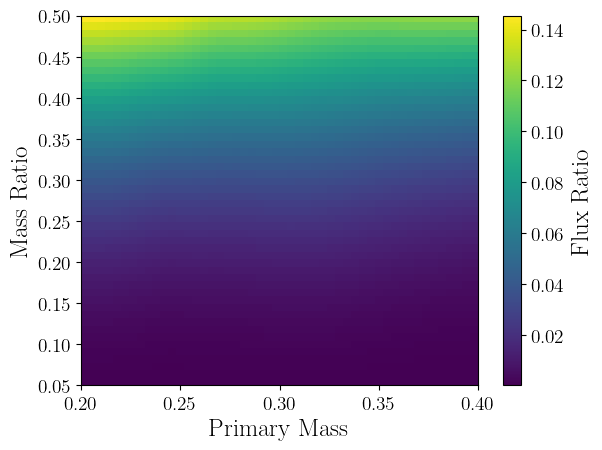

In [111]:
cb = plt.imshow(f_grid_2[:,:,25], origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), qs.min(), qs.max()]);
plt.xlabel("Primary Mass");
plt.ylabel("Mass Ratio");
plt.colorbar(cb, label="Flux Ratio");

Looks lovely. This can be interpolated for any mass/metallicity now.

for interest's sake, we can see what the power law is. It usually sits around 4 but varies considerably. Quite fun.

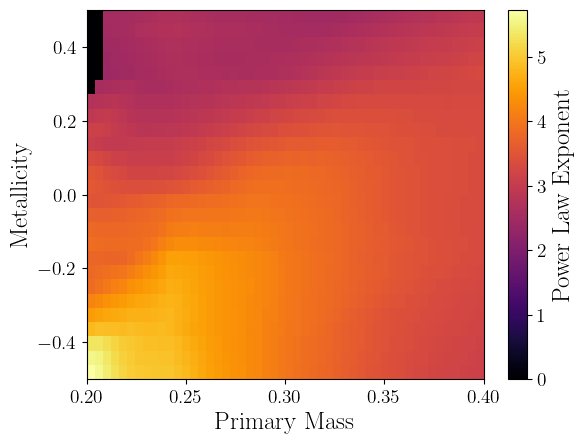

In [112]:
plt.imshow(gammas.T, origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), mhs.min(), mhs.max()], cmap="inferno");
plt.xlabel("Primary Mass");
plt.ylabel("Metallicity");
plt.colorbar(label="Power Law Exponent");

In [113]:
output = {
    "grid": f_grid_2,
    "gammas": gammas,
    "grid_points": [qs, m1s, mhs],
    "note": """this grid is a representation of a function flux ratio = f(mass ratio, primary mass, metallicity)
                The grid was generated by first computing the flux ratio from isochrones at each point, 
                then fitting power laws to fill in any gaps where the isochrone computation failed because they couldn't reach a low enough mass."""}
pickle.dump(output, open("./data/flux_ratio_grid.pkl", "wb"))

#### If we want the flux ratio cut to be $10^{-1.5}$, we can look that up in the grid 

In [122]:
flux_ratio_grid_sup = pickle.load(open("./data/flux_ratio_grid.pkl", "rb"))
flux_ratio_grid = flux_ratio_grid_sup["grid"]
qs, m1s, mhs = flux_ratio_grid_sup["grid_points"]
final_table = Table.read('./data/06_05_26_final_table.fits', format='fits')
final_table.add_column(np.zeros(len(final_table)), name="q_max")

In [124]:
fcut = 10**(-1.5)
q_maxes = []
for row in tqdm(final_table):
    mass_idx = np.argmin(np.abs(m1s - row["mass"]))
    mh_idx = np.argmin(np.abs(mhs - row["mh_single"]))
    q_max = np.interp(fcut, flux_ratio_grid[:, mass_idx, mh_idx], qs)
    q_maxes.append(q_max)
q_maxes = np.array(q_maxes)
final_table["q_max"] = q_maxes
final_table.write('./data/06_05_26_final_table.fits', format='fits', overwrite=True)

  0%|          | 0/383009 [00:00<?, ?it/s]

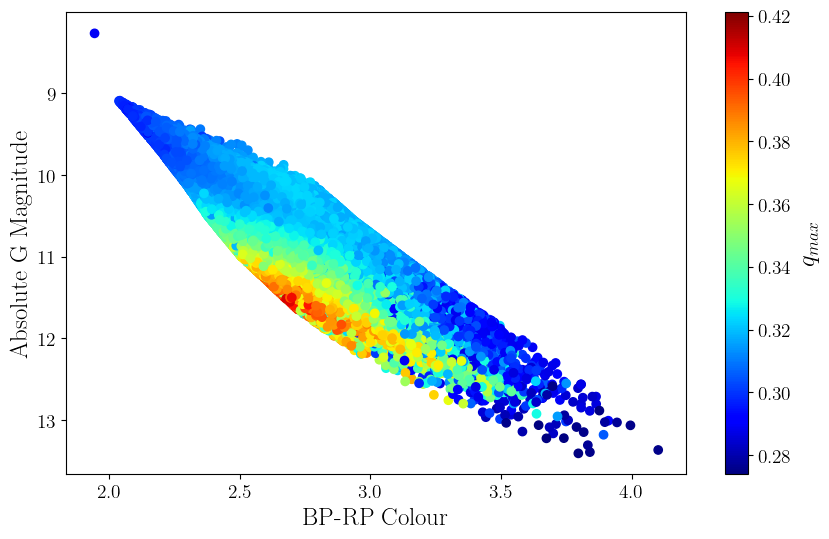

In [119]:
bp_rps = final_table["bp_rp"]
parallax = final_table["parallax"]
gmag = final_table["phot_g_mean_mag"]
absolute_mags = gmag + 5 * np.log10(parallax) - 10

fig, ax = plt.subplots(figsize=(10, 6))
cb = ax.scatter(bp_rps, absolute_mags, c=q_maxes, cmap="jet");
colorbar = plt.colorbar(cb, ax=ax, label=r"$q_{max}$");
ax.invert_yaxis();
ax.set_xlabel("BP-RP Colour");
ax.set_ylabel("Absolute G Magnitude");

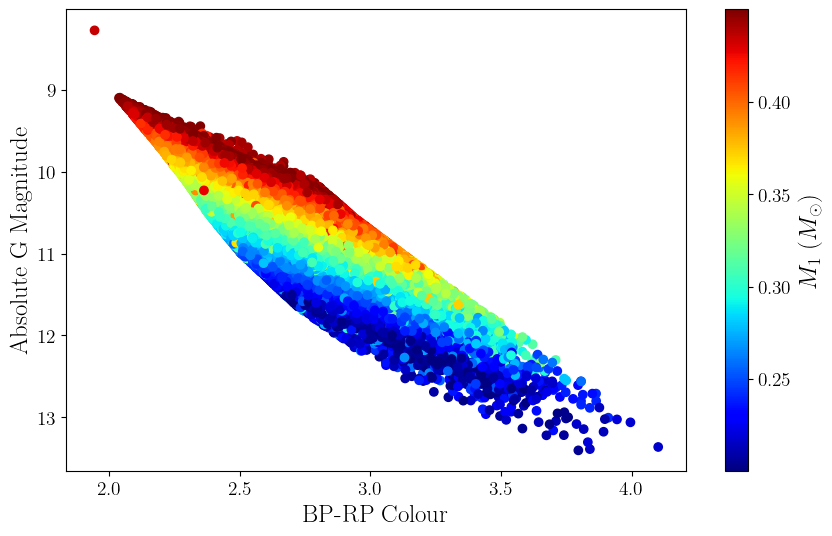

In [120]:
fig, ax = plt.subplots(figsize=(10, 6))
cb = ax.scatter(bp_rps, absolute_mags, c=final_table["mass"], cmap="jet");
colorbar = plt.colorbar(cb, ax=ax, label=r"$M_1$ ($M_\odot$)");
ax.invert_yaxis();
ax.set_xlabel("BP-RP Colour");
ax.set_ylabel("Absolute G Magnitude");

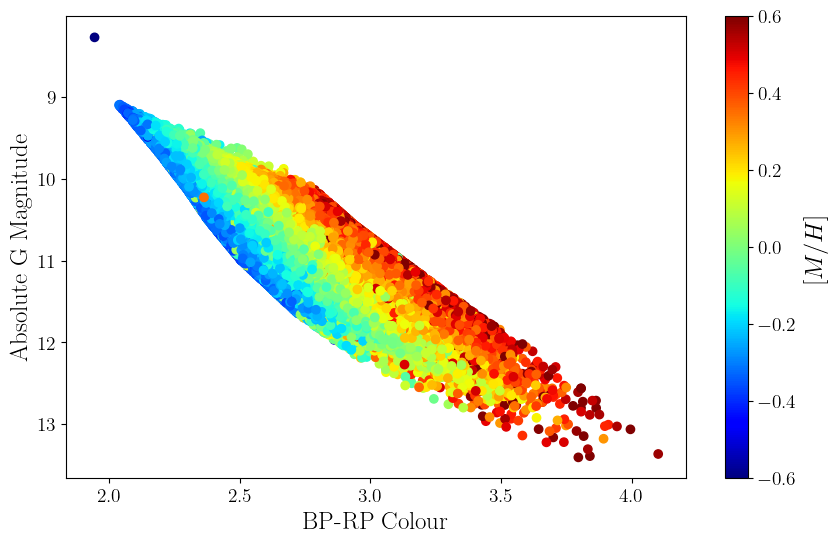

In [98]:
fig, ax = plt.subplots(figsize=(10, 6))
cb = ax.scatter(bp_rps, absolute_mags, c=np.clip(final_table["mh_single"], -0.6, 0.6), cmap="jet");
colorbar = plt.colorbar(cb, ax=ax, label=r"$[M/H]$");
ax.invert_yaxis();
ax.set_xlabel("BP-RP Colour");
ax.set_ylabel("Absolute G Magnitude");

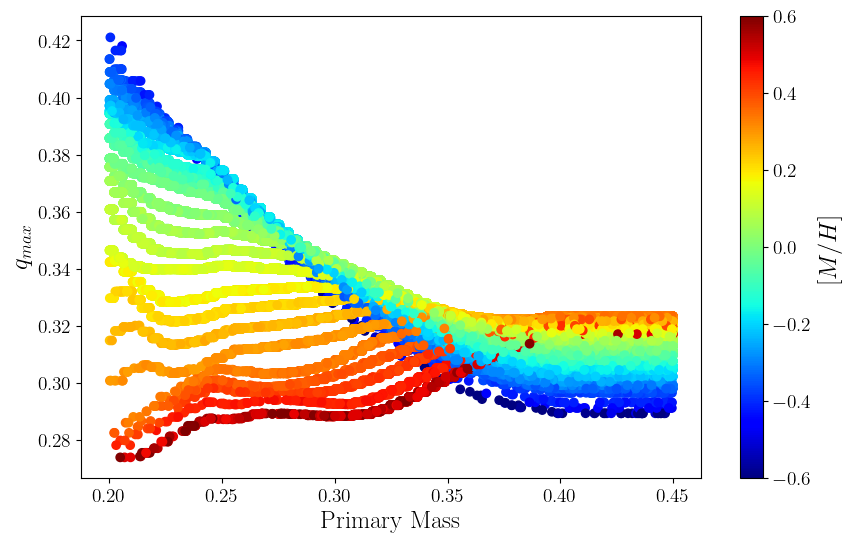

In [121]:
fig, ax = plt.subplots(figsize=(10, 6))
cb = ax.scatter(final_table["mass"], q_maxes, c=np.clip(final_table["mh_single"], -0.6, 0.6), cmap="jet");
colorbar = plt.colorbar(cb, ax=ax, label=r"$[M/H]$");
ax.set_xlabel("Primary Mass");
ax.set_ylabel(r"$q_{max}$");

## So, what is the flux ratio cutoff?

In [166]:
from scipy.interpolate import interpn

In [181]:
small_nss = reduced_nss[(reduced_nss["predicted_class"] == 0) & (reduced_nss["mass_single"] < 0.4) & (reduced_nss["mass_single"] > 0.2)]
labels = ["m2", "fm", "m2_flux"]
for label in labels:
    try:
        small_nss.add_column(np.zeros(len(small_nss)), name=label)
    except:
        pass
    
for row in tqdm(small_nss):
    result_row = small_nss[small_nss["source_id"] == row["source_id"]]
    row["fm"] = mass_function(result_row[0])
    row["m2"] = companion_mass(row["mass_single"], row["fm"])
    row["m2_flux"] = companion_mass_phot(row["mass_single"], row["fm"], row["flux_ratio_mean"])
print(len(small_nss))

  0%|          | 0/292 [00:00<?, ?it/s]

292


In [182]:
small_nss.add_column(np.zeros(len(small_nss)), name="estimated_flux_ratio")

In [183]:
interp_points = (qs, m1s, mhs)
for row in tqdm(small_nss):
    mh = np.clip(row["mh_single"], mhs.min(), mhs.max())
    q = np.clip(row["m2"]/row["mass_single"], qs.min(), qs.max())
    m1 = np.clip(row["mass_single"], m1s.min(), m1s.max())
    
    interp_location = (q, m1, mh) 
    row["estimated_flux_ratio"] = interpn(interp_points, f_grid, interp_location, bounds_error=False, fill_value=0)

  0%|          | 0/292 [00:00<?, ?it/s]

In [187]:
272/292

0.9315068493150684

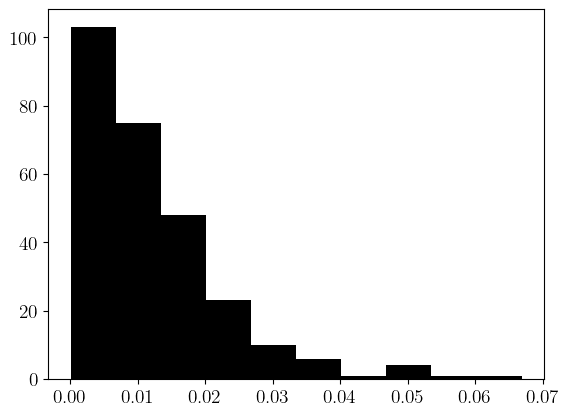

In [ ]:
low_flux = small_nss[small_nss["estimated_flux_ratio"] < 0.1]
plt.hist(low_flux["estimated_flux_ratio"]);

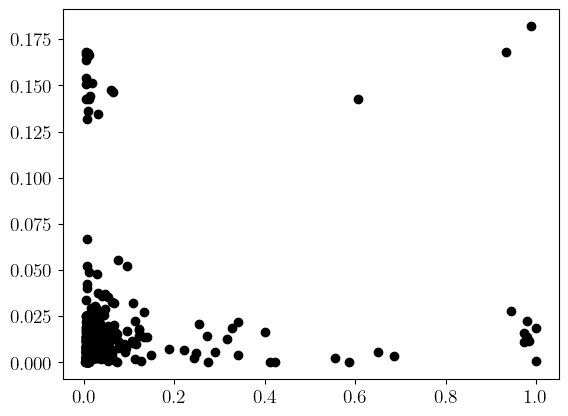

In [195]:
plt.scatter(small_nss["flux_ratio_mean"], small_nss["estimated_flux_ratio"]);

In [228]:
other_nss = reduced_nss[(reduced_nss["predicted_class"] != 0) & (reduced_nss["m1_binary"] < 0.4) & (reduced_nss["m1_binary"] > 0.2)]
labels = ["m2", "fm", "m2_flux"]
for label in labels:
    try:
        other_nss.add_column(np.zeros(len(other_nss)), name=label)
    except:
        pass
    
for row in tqdm(other_nss):
    result_row = other_nss[other_nss["source_id"] == row["source_id"]]
    row["fm"] = mass_function(result_row[0])
    row["m2"] = companion_mass(row["m1_binary"], row["fm"])
    row["m2_flux"] = companion_mass_phot(row["m1_binary"], row["fm"], row["flux_ratio_mean"])
print(len(other_nss))

  0%|          | 0/524 [00:00<?, ?it/s]

524


In [229]:
other_nss.add_column(np.zeros(len(other_nss)), name="estimated_flux_ratio")
interp_points = (qs, m1s, mhs)
for row in tqdm(other_nss):
    mh = np.clip(row["mh_single"], mhs.min(), mhs.max())
    q = np.clip(row["m2"]/row["mass_single"], qs.min(), qs.max())
    m1 = np.clip(row["mass_single"], m1s.min(), m1s.max())
    
    interp_location = (q, m1, mh) 
    row["estimated_flux_ratio"] = interpn(interp_points, f_grid, interp_location, bounds_error=False, fill_value=0)

  0%|          | 0/524 [00:00<?, ?it/s]

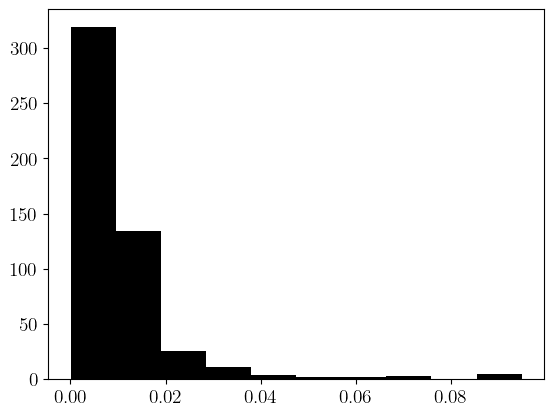

In [230]:
other_lf = other_nss[other_nss["estimated_flux_ratio"] < 0.1]
plt.hist(other_lf["estimated_flux_ratio"]);

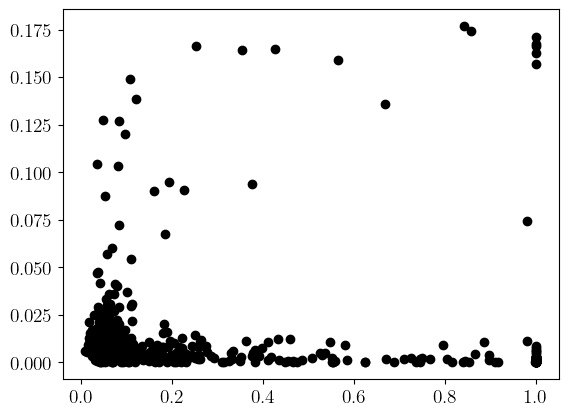

In [231]:
plt.scatter(other_nss["flux_ratio_mean"], other_nss["estimated_flux_ratio"]);

The table should have two parts:

$\texttt{predicted\_class==0}$ and $\texttt{mass\_single}\in[0.2,0.4]$

$\texttt{predicted\_class==1}$ and $\texttt{m1\_binary}\in[0.2,0.4]$

In [222]:
pc0_mask = (working_table["predicted_class"] == 0) & (working_table["mass_single"] < 0.4) & (working_table["mass_single"] > 0.2)
pc1_mask = (working_table["predicted_class"] == 1) & (working_table["m1_binary"] < 0.4) & (working_table["m1_binary"] > 0.2)

class0 = working_table[pc0_mask]
class1 = working_table[pc1_mask]

In [223]:
len(class0), len(class1)

(310832, 84011)

In [246]:
len(class1[class1["flux_ratio_mean"] < 0.03])

2804

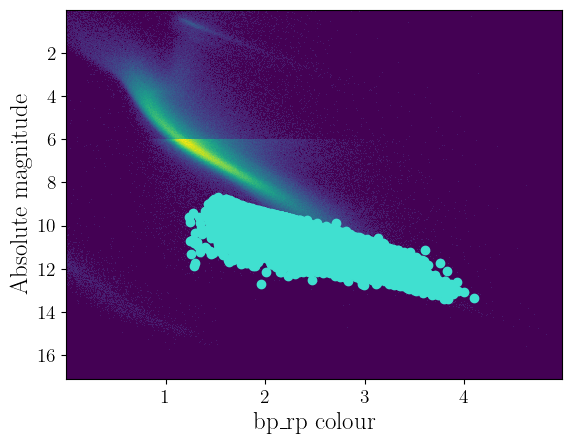

In [224]:
bp_rp = new_table["bp_rp"]
parallax = new_table["parallax"]
gmag = new_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10

plt.hist2d(bp_rp[::5], absolute_magnitudes[::5], bins=1000, norm=matplotlib.colors.PowerNorm(0.4));
plt.ylabel("Absolute magnitude");
plt.xlabel("bp_rp colour");
plt.ylim(bottom=np.max(absolute_magnitudes), top=np.min(absolute_magnitudes));
plt.xlim([np.min(bp_rp), np.max(bp_rp)]);

bp_rp = class0["bp_rp"]
parallax = class0["parallax"]
gmag = class0["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10
plt.scatter(bp_rp, absolute_magnitudes, c="turquoise");

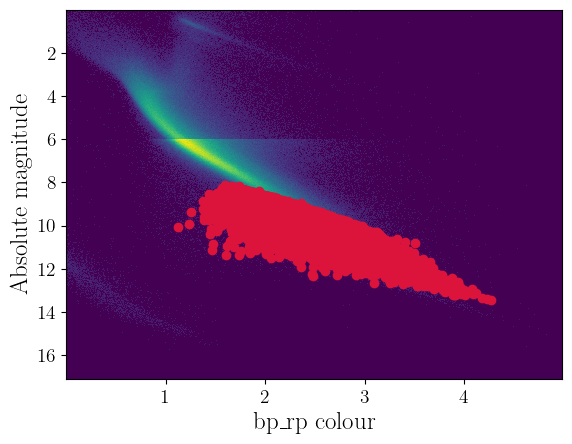

In [225]:
bp_rp = new_table["bp_rp"]
parallax = new_table["parallax"]
gmag = new_table["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10

plt.hist2d(bp_rp[::5], absolute_magnitudes[::5], bins=1000, norm=matplotlib.colors.PowerNorm(0.4));
plt.ylabel("Absolute magnitude");
plt.xlabel("bp_rp colour");
plt.ylim(bottom=np.max(absolute_magnitudes), top=np.min(absolute_magnitudes));
plt.xlim([np.min(bp_rp), np.max(bp_rp)]);

bp_rp = class1["bp_rp"]
parallax = class1["parallax"]
gmag = class1["phot_g_mean_mag"]
absolute_magnitudes = gmag + 5 * np.log10(parallax) - 10
plt.scatter(bp_rp, absolute_magnitudes, c="crimson");

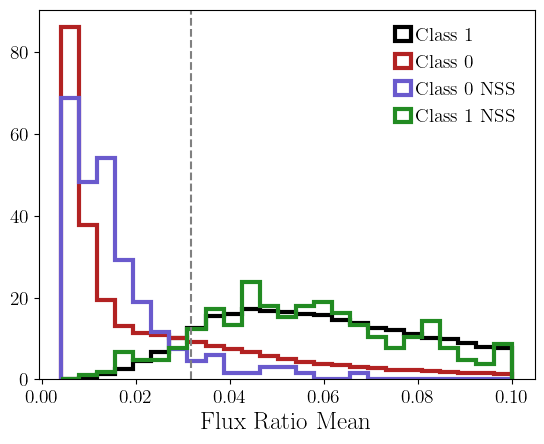

In [264]:
tbins = plt.hist(class1[class1["flux_ratio_mean"] < 0.1]["flux_ratio_mean"], lw=3, density=True, histtype="step", bins=25, label="Class 1");
plt.hist(class0[class0["flux_ratio_mean"] < 0.1]["flux_ratio_mean"], lw=3, density=True, histtype="step", bins=tbins[1], label="Class 0");
plt.hist(small_nss[small_nss["flux_ratio_mean"] < 0.1]["estimated_flux_ratio"], lw=3, density=True, histtype="step", bins=tbins[1], label="Class 0 NSS");
plt.hist(other_nss[other_nss["flux_ratio_mean"] < 0.1]["flux_ratio_mean"], lw=3, density=True, histtype="step", bins=tbins[1], label="Class 1 NSS");
plt.axvline(x=10**(-1.5), color="grey", ls="--");
plt.legend();
plt.xlabel("Flux Ratio Mean");

3% is it!

## The Sample

In [259]:
pc0_mask = (working_table["predicted_class"] == 0) & (working_table["mass_single"] < 0.45) & (working_table["mass_single"] > 0.2)
pc1_mask = (working_table["predicted_class"] == 1) & (working_table["m1_binary"] < 0.45) & (working_table["m1_binary"] > 0.2) & (working_table["flux_ratio_mean"] < 10**(-1.5))

cleaned_sample = working_table[pc0_mask | pc1_mask]

In [260]:
len(working_table), len(cleaned_sample)

(1201659, 405599)

## Trimming to main sequence with isochrones

In [261]:
isochrone_data = np.genfromtxt('../DR3_planet_candidate_identification/data/isochrones.dat',
                     skip_header=13,
                     skip_footer=1,
                     names=True,
                     dtype=None)
print(np.unique(isochrone_data["logAge"]))
print(np.unique(isochrone_data["MH"]))

def outside_isochrones(iso_x, iso_y, target_point):
    return np.interp(x=target_point[0], xp=iso_x, fp=iso_y) > target_point[1]

[7.      7.1     7.2     7.3     7.4     7.5     7.6     7.7     7.8
 7.9     8.      8.1     8.2     8.3     8.4     8.5     8.6     8.7
 8.8     8.9     9.      9.1     9.2     9.3     9.4     9.5     9.60001
 9.70001 9.80001 9.90001]
[-0.6 -0.5 -0.4 -0.3 -0.2 -0.1 -0.   0.1  0.2  0.3]


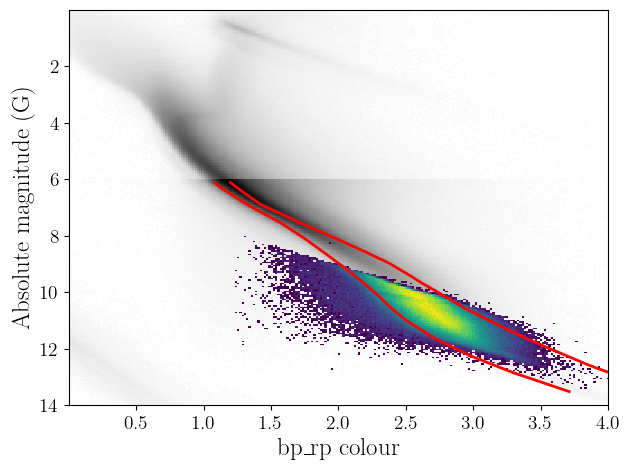

In [268]:
bp_rps = cleaned_sample["bp_rp"]
parallax = cleaned_sample["parallax"]
gmag = cleaned_sample["phot_g_mean_mag"]
absolute_mags = gmag + 5 * np.log10(parallax) - 10

fig, ax = plt.subplots(1, 1)

bp_rp_all = new_table["bp_rp"]
parallax_all = new_table["parallax"]
gmag_all = new_table["phot_g_mean_mag"]
absolute_magnitudes_all = gmag_all + 5 * np.log10(parallax_all) - 10

# --- Background (full dataset) ---
H_bg, xedges, yedges, _ = plt.hist2d(
    bp_rp_all,
    absolute_magnitudes_all,
    bins=300,
    cmap="binary",
    norm=matplotlib.colors.PowerNorm(0.4),
    zorder=1
)

# --- Foreground histogram (compute only) ---
H_fg, _, _ = np.histogram2d(
    bp_rps,
    absolute_mags,
    bins=[xedges, yedges]  # IMPORTANT: same binning
)

# Mask zero bins
H_fg_masked = np.ma.masked_where(H_fg == 0, H_fg)

# Colormap with transparent "bad" values
cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0)  # <-- makes masked bins invisible

# Plot foreground
plt.pcolormesh(
    xedges,
    yedges,
    H_fg_masked.T,
    cmap=cmap,
    norm=matplotlib.colors.PowerNorm(0.4),
    zorder=2
)

# fig, ax = plt.subplots(1, 1)

#plt.hist2d(bp_rps, absolute_mags, bins=1000, norm=matplotlib.colors.PowerNorm(0.4));

isochrone_mags = isochrone_data["Gmag"]
isochrone_cols = isochrone_data["G_BPmag"] - isochrone_data["G_RPmag"]
edge_mask = (isochrone_cols < 4.5) & (isochrone_mags > 6) & (isochrone_mags < 14) & (isochrone_data["MH"] == -0.3) & (isochrone_data["logAge"] == 9.90001)
edge_isochrone_cols, edge_isochrone_mags = isochrone_cols[edge_mask], isochrone_mags[edge_mask]
plt.plot(edge_isochrone_cols, edge_isochrone_mags, c="r", linewidth=2, label="M/H=-0.3, logAge=9.9");

isochrone_mags = isochrone_data["Gmag"]
isochrone_cols = isochrone_data["G_BPmag"] - isochrone_data["G_RPmag"]
upper_mask = (isochrone_mags < 14) & (isochrone_mags > 6) & (isochrone_cols < 5) & (isochrone_data["MH"] == 0.3) & (isochrone_data["logAge"] == 8)
edge_isochrone_cols, edge_isochrone_mags = isochrone_cols[upper_mask], isochrone_mags[upper_mask]
plt.plot(edge_isochrone_cols, edge_isochrone_mags, c="r", linewidth=2);

ax.invert_yaxis()
ax.set_ylim(bottom=14) #[14, 6])
ax.set_xlim(right=4)#[0.5,4])
ax.set_ylabel("Absolute magnitude (G)");
ax.set_xlabel("bp_rp colour");

plt.tight_layout();
#plt.savefig("./plots/isochrone_cuts.jpg", dpi=800);

In [276]:
def get_sorted_isochrone_points(isochrone_mags, isochrone_cols, edge_mask, get_edgevals=False):
    edge_isochrone_cols, edge_isochrone_mags = isochrone_cols[edge_mask], isochrone_mags[edge_mask]
    if get_edgevals:
        return edge_isochrone_cols, edge_isochrone_mags
    coords = list(zip(edge_isochrone_mags, edge_isochrone_cols))
    coords.sort()
    x_sorted, y_sorted = zip(*coords)
    return x_sorted, y_sorted

x_sorted, y_sorted = get_sorted_isochrone_points(isochrone_mags, isochrone_cols, edge_mask)

u_x_sorted, u_y_sorted = get_sorted_isochrone_points(isochrone_mags, isochrone_cols, upper_mask)

table_isochrone_mask = np.invert(outside_isochrones(x_sorted, y_sorted, (absolute_mags, bp_rps))) & outside_isochrones(u_x_sorted, u_y_sorted, (absolute_mags, bp_rps))
final_table = cleaned_sample[table_isochrone_mask]
rejected = cleaned_sample[np.invert(table_isochrone_mask)]

In [277]:
len(final_table), len(rejected), f"{len(rejected)/len(cleaned_sample)*100:.2f}% rejected by isochrone cut"

(383009, 22590, '5.57% rejected by isochrone cut')

In [278]:
final_table.write("./data/06_05_26_final_table.fits", overwrite=True)

## Pulling parameters from Gaia

In [36]:
final_table = Table.read('./data/06_05_26_final_table.fits', format='fits')

In [40]:
job = Gaia.launch_job_async(r"""select pmra, pmdec, ruwe, phot_g_mean_flux, phot_g_mean_flux_error
                        from gaiadr3.gaia_source 
                        where source_id = 5478926884285078784""")
results = job.get_results()

INFO: Query finished. [astroquery.utils.tap.core]


In [5]:
import os
os.environ["XDG_CACHE_HOME"] = os.path.expanduser("~/.astroquery_tmp")

In [42]:
import time

In [43]:
def chunk_list(lst, n):
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

batch_size = 10000

all_results = []
counter = 0

for batch in tqdm(list(chunk_list(final_table["source_id"], batch_size))):
    ids_str = ",".join(str(sid) for sid in batch)
    query = f"""
    SELECT source_id, pmra, pmdec, ruwe, phot_g_mean_flux, phot_g_mean_flux_error
    FROM gaiadr3.gaia_source
    WHERE source_id IN ({ids_str})
    """
    complete = False
    while not complete:
        try:
            job = Gaia.launch_job_async(query, verbose=False)
            results = job.get_results()
            complete = True
        except:
            print(f"{counter} Failed")
        time.sleep(1)

    all_results.append(results.to_pandas())
    counter += 1

df = pd.concat(all_results, ignore_index=True)

  0%|          | 0/39 [00:00<?, ?it/s]

INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]
INFO: Query finished. [astroquery.utils.tap.core]


### append solution types

In [44]:
nss_table = Table.read('../BigData/NSSTableKpc.fits', format='fits')
accel_table = Table.read('../BigData/AccelTableKpc.fits', format='fits')
nss_table = nss_table[(nss_table["parallax"] < 20) & (nss_table["parallax"] > 5)]
accel_table = accel_table[(accel_table["parallax"] < 20) & (accel_table["parallax"] > 5)]

In [ ]:
final_table.add_column(np.zeros(len(final_table)), name="phot_g_mean_flux")
final_table.add_column(np.zeros(len(final_table)), name="phot_g_mean_flux_error")
final_table.add_column(np.zeros(len(final_table)), name="pmra")
final_table.add_column(np.zeros(len(final_table)), name="pmdec")
final_table.add_column(np.zeros(len(final_table)), name="ruwe")
final_table.add_column(np.zeros(len(final_table)), name="solution_type")

In [47]:
mask = np.isin(final_table["source_id"], df["source_id"])  # boolean mask for rows to update
data_indices = np.where(mask)[0]

# Step 2: Map update indices
update_map = {sid: i for i, sid in enumerate(df['source_id'])}

# Step 3: Update only the desired columns
for col in ['pmra', 'pmdec', 'ruwe', 'phot_g_mean_flux', 'phot_g_mean_flux_error']: #, 'period', 'eccentricity']:
    # Pick corresponding values from updates_df
    final_table[col][data_indices] = [df[col][update_map[sid]] for sid in final_table['source_id'][data_indices]]

In [11]:
accel_ids = list(accel_table["source_id"])
nss_ids = list(nss_table["source_id"])

for row in tqdm(final_table):
    if row["ruwe"] < 1.4:
        row["solution_type"] = int(0)
    elif row["source_id"] in nss_ids:
        row["solution_type"] = int(12)
    elif row["source_id"] in accel_ids:
        if accel_table[accel_table["source_id"] == row["source_id"]]["nss_solution_type"][0] == "Acceleration7":
            row["solution_type"] = int(7)
        elif accel_table[accel_table["source_id"] == row["source_id"]]["nss_solution_type"][0] == "Acceleration9":
            row["solution_type"] = int(9)
    else:
        row["solution_type"] = int(5)

  0%|          | 0/383009 [00:00<?, ?it/s]

### make a unifying mass

In [20]:
final_table.add_column(np.zeros(len(final_table)), name="mass")
for row in tqdm(final_table):
    if row["predicted_class"] == 0:
        row["mass"] = row["mass_single"]
    else:
        row["mass"] = row["m1_binary"]

  0%|          | 0/383009 [00:00<?, ?it/s]

### Prepare a nice orbit solution catalogue

In [12]:
relevant_things = ["source_id", "parallax", "ra", "dec", "phot_g_mean_mag", "mass_single", "m1_binary", "m2_binary", "predicted_class", "bp_rp", "mh_single", "q_binary", "flux_ratio_mean", "flux_ratio_std", "chi2_mass_mh", "chi2_mass_mh_binary", "chi2_diff_mh_mass", "fit_success_single", "fit_success_binary"]
for col in relevant_things:
    if col not in nss_table.keys():
        nss_table.add_column(np.zeros(len(nss_table)), name=col)

In [14]:
reduced_nss = Table(names=nss_table.colnames, dtype=[nss_table[col].dtype for col in nss_table.colnames])
for obj in tqdm(nss_table):
    source_id = obj["source_id"]
    if source_id in final_table["source_id"]:
        target_row = final_table[final_table["source_id"] == source_id][0]
        for col in relevant_things:
            obj[col] = target_row[col]
                
        reduced_nss.add_row(obj)

  0%|          | 0/16504 [00:00<?, ?it/s]

In [16]:
labels = ["m2", "fm", "m2_flux"]
for label in labels:
    try:
        reduced_nss.add_column(np.zeros(len(reduced_nss)), name=label)
    except:
        pass
    
for row in tqdm(reduced_nss):
    result_row = reduced_nss[reduced_nss["source_id"] == row["source_id"]]
    row["fm"] = mass_function(result_row[0])
    row["m2"] = companion_mass(row["mass_single"], row["fm"])
    row["m2_flux"] = companion_mass_phot(row["mass_single"], row["fm"], row["flux_ratio_mean"])

  0%|          | 0/487 [00:00<?, ?it/s]

In [17]:
reduced_nss.write("./data/06_05_26_orbit_solutions.fits", overwrite=True)

In [48]:
final_table.write("./data/06_05_26_final_table.fits", overwrite=True)

## So, what have we got?

In [2]:
final_table = Table.read('./data/06_05_26_final_table.fits', format='fits')

In [31]:
bincount = 15
masses = np.percentile(final_table["mass"], np.linspace(0,100,bincount+1))
r = np.zeros(bincount)
ruwes = np.zeros(bincount)
for i in range(bincount):
    tcat = final_table[(final_table["mass"] > masses[i]) & (final_table["mass"] <= masses[i+1])]
    rate = len(tcat[[t["solution_type"] == 0 for t in tcat]])/len(tcat)*100
    r[i] = rate
    ruwes[i] = np.median(tcat["ruwe"])
    print_table(tcat, label=f"Mass: {masses[i]:.3f}-{masses[i+1]:.3f}")

,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,97.93,1.84,0.14,0.05,0.05
Counts,25533,25004,469,36,12,12


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,97.49,2.24,0.12,0.07,0.09
Counts,25534,24892,572,30,17,23


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,96.94,2.76,0.15,0.05,0.10
Counts,25534,24753,704,38,12,24


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,96.59,3.18,0.12,0.04,0.07
Counts,25534,24664,811,31,9,19


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,96.30,3.42,0.13,0.07,0.08
Counts,25534,24589,872,33,19,21


...

,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,94.17,5.37,0.24,0.08,0.13
Counts,25534,24046,1372,61,21,34


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,93.12,6.31,0.30,0.12,0.15
Counts,25534,23777,1611,76,31,38


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,92.86,6.48,0.32,0.13,0.21
Counts,25534,23710,1654,82,34,53


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,92.51,6.69,0.38,0.17,0.24
Counts,25534,23622,1709,97,44,62


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,92.05,7.21,0.34,0.19,0.21
Counts,25534,23505,1840,86,48,53


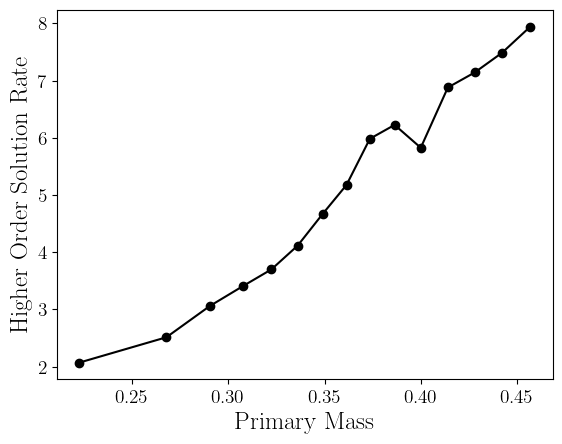

In [32]:
plt.plot(masses[:-1]+(masses[1]-masses[0])/2, 100-r, marker="o");
plt.xlabel("Primary Mass");
plt.ylabel("Higher Order Solution Rate");

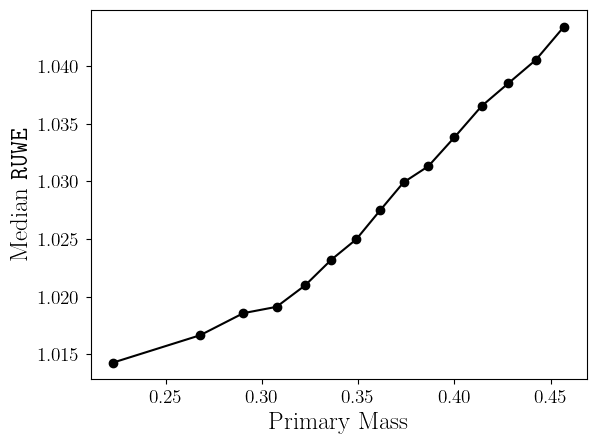

In [33]:
plt.plot(masses[:-1]+(masses[1]-masses[0])/2, ruwes, marker="o");
plt.xlabel("Primary Mass");
plt.ylabel(r"Median $\texttt{RUWE}$");

## "corner" plot

In [34]:
final_table["distance"] = 1000/final_table["parallax"]
final_table["logruwe"] = np.log10(final_table["ruwe"])

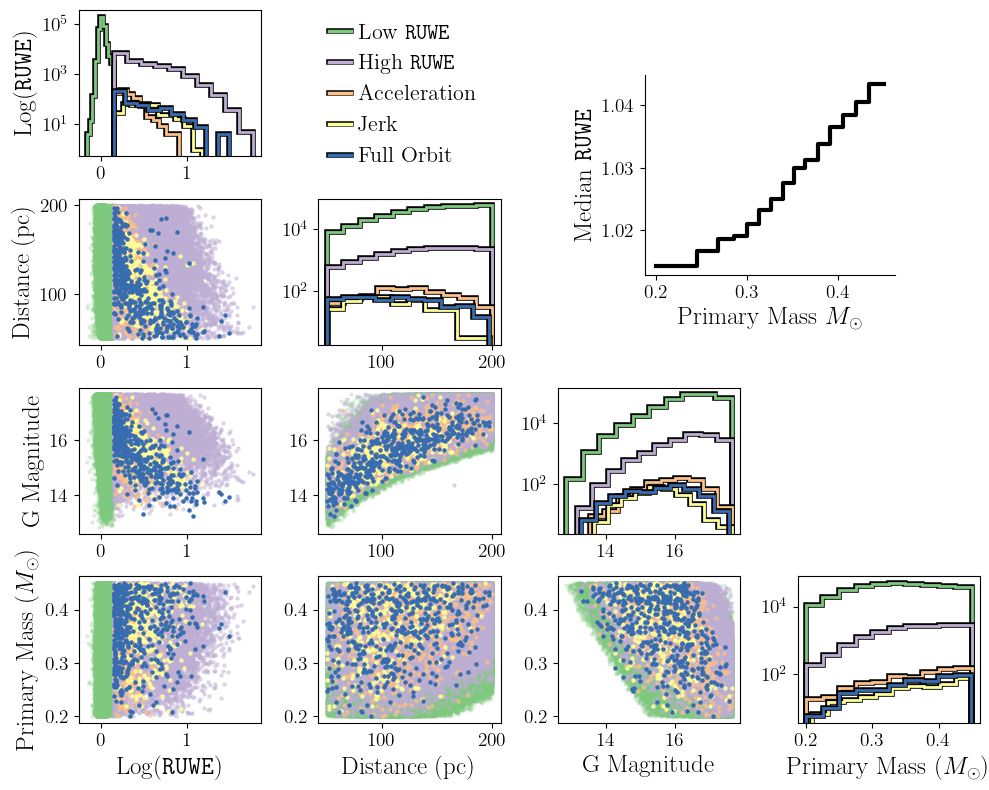

In [35]:
params = ["logruwe", "distance", "phot_g_mean_mag", "mass"]
labels = [r"\text{Log}(\texttt{RUWE})", "Distance (pc)", "G Magnitude", r"Primary Mass ($M_\odot$)"]
type_labels = [r"Low \texttt{RUWE}", r"High \texttt{RUWE}", "Acceleration", "Jerk", "Full Orbit"]
soltypes = [0,5,7,9,12]
colors = plt.get_cmap('Accent')(np.linspace(0, 1, 8))[:5]

n = len(params)
fig, axes = plt.subplots(n, n, figsize=(10, 8))

nbins=15

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i < j:
            ax.axis('off')
            continue

        for t in range(5):
            subset = final_table[final_table["solution_type"] == soltypes[t]]
            x = subset[params[j]]
            y = subset[params[i]]

            if i == j:
                #ax.hist(x, color="k", histtype="step", lw=4)
                ax.hist(x, color=colors[t], #range=(np.min(final_table[params[i]]), np.max(final_table[params[j]])), bins=nbins,
                        histtype="step", lw=2, 
                        path_effects=[
                        pe.Stroke(linewidth=4, foreground='black'),  # outline
                        pe.Normal()])
                ax.set_yscale("log")
            else:
                ax.scatter(x, y, s=5, color=colors[t], alpha=0.2*(t+1))

        if i == n-1:
            ax.set_xlabel(labels[j])
        if j == 0:
            ax.set_ylabel(labels[i])

# Create legend handles
handles = [
    matplotlib.lines.Line2D([0, 1], [0, 0],      # defines a line segment
           color=colors[t],     # your color per type
           lw=2.5,              # line width
           linestyle='-',       # solid line (can change)
           label=type_labels[t],
           path_effects=[
               pe.Stroke(linewidth=4, foreground='black'),  # outline
               pe.Normal()                                  # actual line on top
           ])
    for t in range(5)
]

# Add legend to figure (not individual axes)
fig.legend(
    handles=handles,
    loc='upper right',
    bbox_to_anchor=(0.50, 0.99),
    frameon=False,       # removes boundary box
    fontsize=16,         # bigger text
    handlelength=1,      # longer lines
)

plt.tight_layout()

inset_ax = fig.add_axes([0.65, 0.65, 0.25, 0.25]) 

# compute bins for drawing
mass_lims_b = np.percentile(final_table["mass"], np.linspace(0,100,bincount+1))
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

# draw median RUWE
pts = ruwes
inset_ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(pts,2), lw=3);
inset_ax.set_xlabel(r"Primary Mass $M_\odot$");
inset_ax.set_ylabel(r"Median \texttt{RUWE}");
inset_ax.spines['top'].set_visible(False)
inset_ax.spines['right'].set_visible(False)

#plt.savefig("./plots/SampleCornerCombined.jpg", dpi=800);